In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [23]:
# Get the current working directory
folder_name =   "f6_output/"
current_dir = os.getcwd() + "/" + folder_name

# List all CSV files in the current working directory
csv_files = [f for f in os.listdir(current_dir) if f.endswith('.csv')]

# Read each CSV file into a DataFrame and store them in a list
dataframes = []
for file in csv_files:
    print(folder_name+file)

spreadsheet = pd.read_csv("f6_output/spatial_pd_demographic experiment-spreadsheet.csv", usecols=lambda column: column != "[all run data]", on_bad_lines="warn", header=28)

print(spreadsheet.head(10))
print(len(spreadsheet))

f6_output/spatial_pd_demographic experiment-lists.csv
f6_output/spatial_pd_demographic experiment-spreadsheet.csv
f6_output/spatial_pd_demographic experiment-stats.csv
f6_output/spatial_pd_demographic experiment-table.csv
   [step]  count turtles  count cooperators  count defectors  [step].1  \
0       0            280                140              140         0   
1       1            305                147              158         1   
2       2            320                139              181         2   
3       3            356                172              184         3   
4       4            414                247              167         4   
5       5            572                414              158         5   
6       6            790                610              180         6   
7       7           1031                811              220         7   
8       8           1249                982              267         8   
9       9           1462              

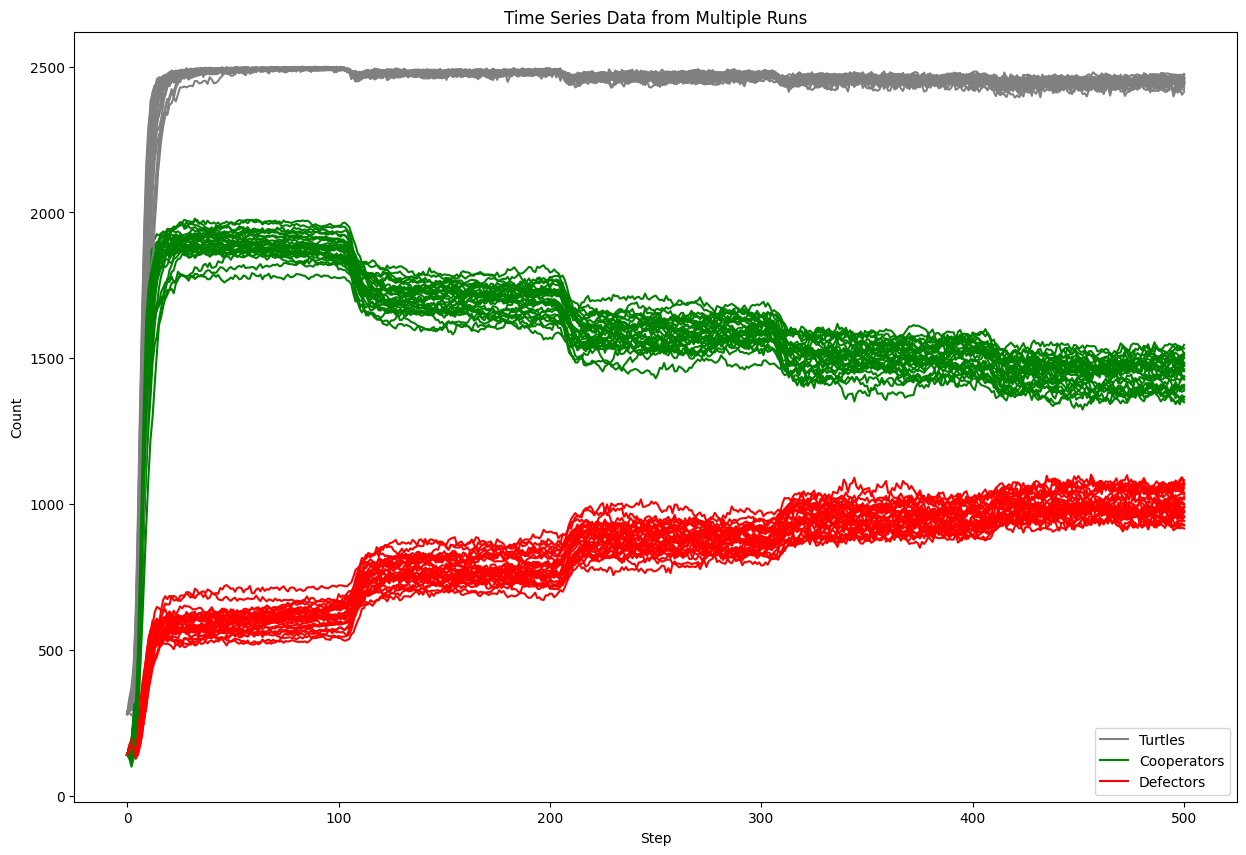

In [36]:
# Get the number of unique runs by identifying unique step columns
step_columns = [col for col in spreadsheet.columns if 'step' in col]
num_runs = len(step_columns)

# Initialize lists to store cooperators and defectors time series
cooperators_list = []
defectors_list = []
turtles_list = []

# Create a plot
plt.figure(figsize=(15, 10))

# Plot each time series for each run
for i in range(num_runs):
    # Extract columns for each run
    step_col = step_columns[i]
    turtles_col = f'count turtles.{i}' if i > 0 else 'count turtles'
    cooperators_col = f'count cooperators.{i}' if i > 0 else 'count cooperators'
    defectors_col = f'count defectors.{i}' if i > 0 else 'count defectors'
    
    # needed for 2nd diagram
    cooperators_list.append(spreadsheet[cooperators_col])
    defectors_list.append(spreadsheet[defectors_col])
    turtles_list.append(spreadsheet[turtles_col])

    # Plot each metric for the current run
    plt.plot(spreadsheet[step_col], spreadsheet[turtles_col], label=f'Turtles Run {i+1}', color="gray")
    plt.plot(spreadsheet[step_col], spreadsheet[cooperators_col], label=f'Cooperators Run {i+1}', color="green")
    plt.plot(spreadsheet[step_col], spreadsheet[defectors_col], label=f'Defectors Run {i+1}', color="red")

# Customize the plot
plt.xlabel('Step')
plt.ylabel('Count')
plt.title('Time Series Data from Multiple Runs')
plt.legend(["Turtles", "Cooperators", "Defectors"])
plt.show()

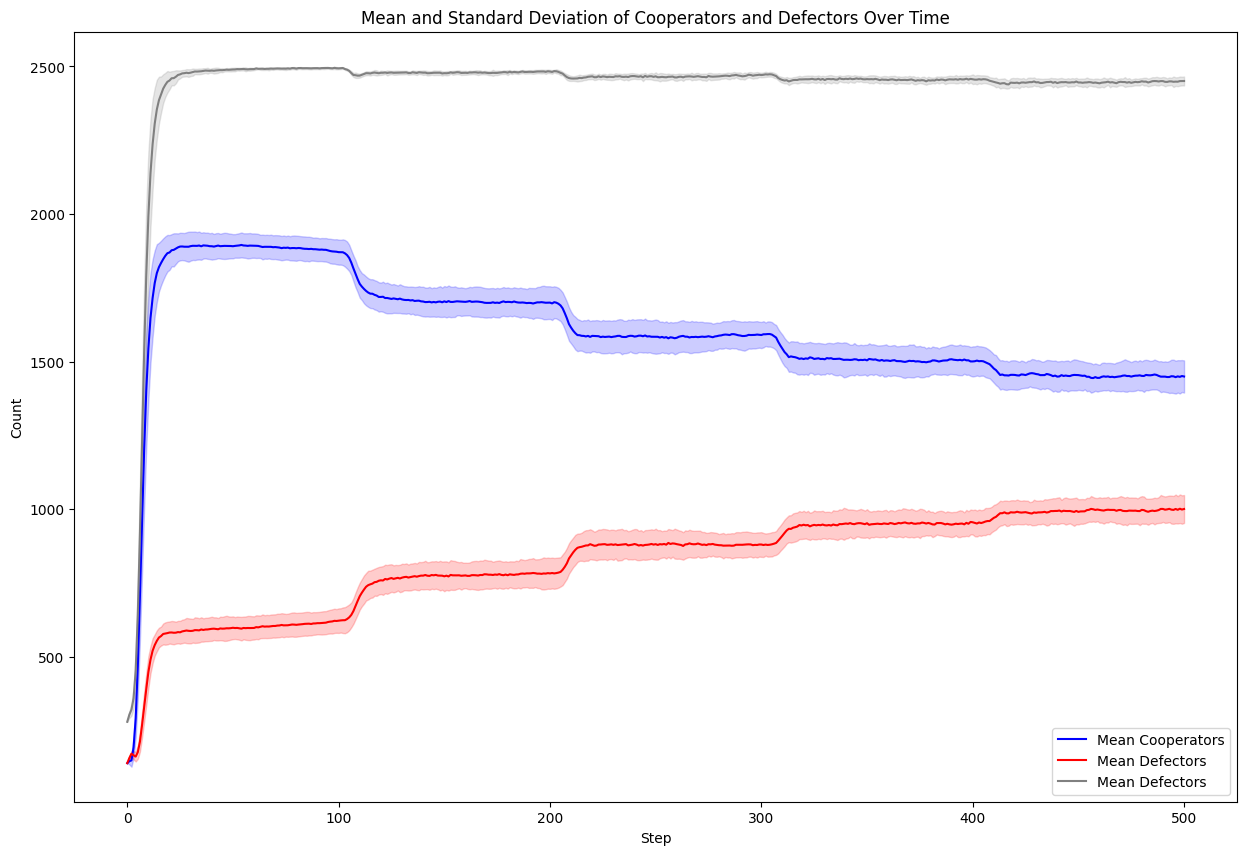

In [39]:
# Convert lists to DataFrames for easier manipulation
cooperators_df = pd.DataFrame(cooperators_list).transpose()
defectors_df = pd.DataFrame(defectors_list).transpose()
turtles_df = pd.DataFrame(turtles_list).transpose()

# Calculate mean and standard deviation for each timestep
mean_cooperators = cooperators_df.mean(axis=1)
std_cooperators = cooperators_df.std(axis=1)
mean_defectors = defectors_df.mean(axis=1)
std_defectors = defectors_df.std(axis=1)
mean_turtles = turtles_df.mean(axis=1)
std_turtles = turtles_df.std(axis=1)

# Assuming all runs have the same steps, use the first step column for x-axis
steps = spreadsheet[step_columns[0]]

# Plot the mean time series with error bands
plt.figure(figsize=(15, 10))

# Plot mean and standard deviation for cooperators
plt.plot(steps, mean_cooperators, label='Mean Cooperators', color='green')
plt.fill_between(steps, mean_cooperators - std_cooperators, mean_cooperators + std_cooperators, color='green', alpha=0.2)

# Plot mean and standard deviation for defectors
plt.plot(steps, mean_defectors, label='Mean Defectors', color='red')
plt.fill_between(steps, mean_defectors - std_defectors, mean_defectors + std_defectors, color='red', alpha=0.2)


# Plot mean and standard deviation for defectors
plt.plot(steps, mean_turtles, label='Mean Defectors', color='gray')
plt.fill_between(steps, mean_turtles - std_turtles, mean_turtles + std_turtles, color='gray', alpha=0.2)
# Customize the plot
plt.xlabel('Step')
plt.ylabel('Count')
plt.title('Mean and Standard Deviation of Cooperators and Defectors Over Time')
plt.legend(loc='best')
plt.show()